In [1]:
import numpy as np

n_samples = 500
np.random.seed(0)
C = np.array([[0.0, -0.1], [1.7, 0.4]])
component_1 = np.dot(np.random.randn(n_samples, 2), C)  # general
component_2 = 0.7 * np.random.randn(n_samples, 2) + np.array([-4, 1])  # spherical

X = np.concatenate([component_1, component_2])

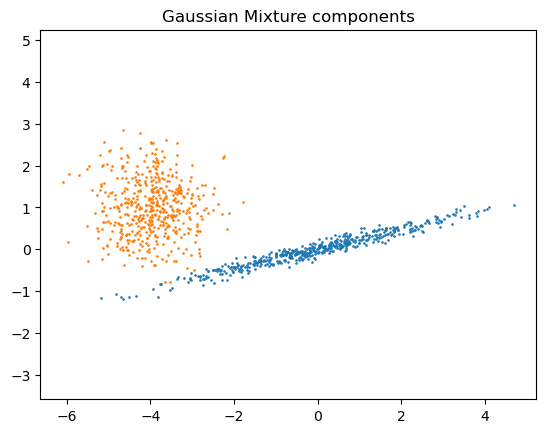

In [2]:
import matplotlib.pyplot as plt

plt.scatter(component_1[:, 0], component_1[:, 1], s=0.8)
plt.scatter(component_2[:, 0], component_2[:, 1], s=0.8)
plt.title("Gaussian Mixture components")
plt.axis("equal")
plt.show()

In [3]:
import numpy as np
from scipy.special import logsumexp


def gaussian_logpdf(x, mean, cov):
    """
    Log probability of multivariate Gaussian.

    x    : (N, D)
    mean : (D,)
    cov  : (D, D)
    """

    diff = x - mean

    sign, logdet = np.linalg.slogdet(cov)

    if sign <= 0:
        raise ValueError("Covariance matrix must be positive definite.")

    # Do not explicitly calculate inverse
    tmp = np.linalg.solve(cov, diff.T).T

    mahal = np.sum(diff * tmp, axis=1)

    D = x.shape[1]

    return -0.5 * (
        D * np.log(2.0 * np.pi)
        + logdet
        + mahal
    )

In [4]:
def gmm_e_step(x, weights, means, covariances):
    """
    Calculate responsibility gamma_ik.

    x           : (N, D)
    weights     : (K,)
    means       : (K, D)
    covariances : (K, D, D)
    """

    N = x.shape[0]
    K = len(weights)

    log_prob = np.zeros((N, K))

    for k in range(K):

        log_prob[:, k] = (
            np.log(weights[k])
            + gaussian_logpdf(
                x,
                means[k],
                covariances[k]
            )
        )

    # log p(x_i)
    log_norm = logsumexp(
        log_prob,
        axis=1,
        keepdims=True
    )

    # responsibility
    gamma = np.exp(log_prob - log_norm)

    return gamma

In [5]:
def gmm_m_step(x, gamma, reg_covar=1e-6):

    N, D = x.shape
    K = gamma.shape[1]

    Nk = np.sum(gamma, axis=0)

    weights = Nk / N

    means = np.zeros((K, D))
    covariances = np.zeros((K, D, D))

    for k in range(K):

        # mean
        means[k] = (
            gamma[:, k, None] * x
        ).sum(axis=0) / Nk[k]

        # covariance
        diff = x - means[k]

        covariances[k] = (
            (gamma[:, k, None] * diff).T
            @ diff
        ) / Nk[k]

        # Prevent singular covariance
        covariances[k] += (
            reg_covar * np.eye(D)
        )

    return weights, means, covariances

In [59]:
maxiter = 10
weights = np.array([0.5, 0.5])

means = np.array([
    [-3, 0],
    [0, 0]
])

covariances = np.array([
    [[0.5, 0.00],
     [0.00, 0.5]],

    [[0.5, 0.00],
     [0.00, 0.5]]
])
for i in range(maxiter):

    gamma = gmm_e_step(
        X,
        weights,
        means,
        covariances
    )

    weights, means, covariances = gmm_m_step(
        X,
        gamma
    )

In [60]:
weights, means, covariances

(array([0.49973327, 0.50026673]),
 array([[-3.98537910e+00,  1.00373685e+00],
        [-4.41495934e-02, -2.98352568e-03]]),
 array([[[ 0.46616664, -0.00738281],
         [-0.00738281,  0.45651113]],
 
        [[ 2.88905544,  0.67854353],
         [ 0.67854353,  0.16882837]]]))

In [61]:
import seaborn as sns



In [62]:
Y_ = np.argmax(gamma, axis=1)

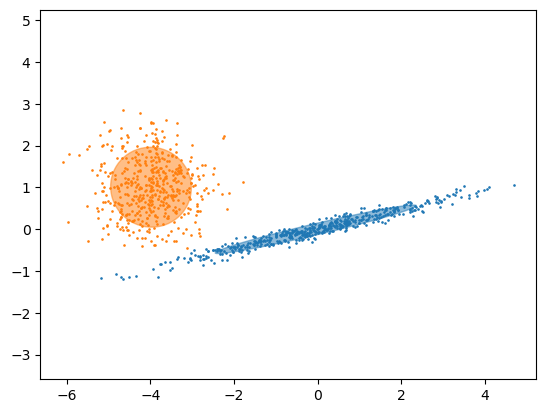

In [63]:
from matplotlib.patches import Ellipse
from scipy import linalg

color_iter = sns.color_palette("tab10", 2)[::-1]

fig, ax = plt.subplots()

for i, (mean, cov, color) in enumerate(
    zip(
        means,
        covariances,
        color_iter,
    )
):
    v, w = linalg.eigh(cov)
    if not np.any(Y_ == i):
        continue
    plt.scatter(X[Y_ == i, 0], X[Y_ == i, 1], 0.8, color=color)

    angle = np.arctan2(w[0][1], w[0][0])
    angle = 180.0 * angle / np.pi  # convert to degrees
    v = 2.0 * np.sqrt(2.0) * np.sqrt(v)
    ellipse = Ellipse(mean, v[0], v[1], angle=180.0 + angle, color=color)
    ellipse.set_clip_box(fig.bbox)
    ellipse.set_alpha(0.5)
    ax.add_artist(ellipse)

plt.axis("equal")
plt.show()